# Базовая очередь M/M/2

Воспроизводится пример методических указаний: десять клиентов, два канала,
интенсивности поступления и обслуживания 0,9 и 0,5, генератор StableRNG(123).

In [1]:
using DrWatson
@quickactivate "EventSystemsStudy"
ENV["GKSwstype"] = "100"
include(srcdir("EventSystemsStudy.jl"))
using .EventSystemsStudy.QueueFlow, .EventSystemsStudy.EvidenceIO
using DataFrames, Plots

## Имитационный прогон

In [2]:
result = run_queue(clients=10, channels=2, arrival_rate=0.9,
    service_rate=0.5, seed=123)
observed = queue_indicators(result)
theory = erlang_c_indicators(0.9, 0.5, 2)
store_table("queue_baseline", "clients.csv", result.ledger)
store_table("queue_baseline", "states.csv", result.states)
store_table("queue_baseline", "comparison.csv", DataFrame([
    (source="simulation", Wq=observed.Wq, W=observed.W, Lq=observed.Lq,
        L=observed.L, p_wait=observed.p_wait),
    (source="Erlang C", Wq=theory.Wq, W=theory.W, Lq=theory.Lq,
        L=theory.L, p_wait=theory.p_wait)]))

"/workspace/labs/lab07/project/data/queue_baseline/comparison.csv"

## События и результат

10×7 DataFrame
 Row │ client  arrival   service_start  departure  waiting   service   system
     │ Int64   Float64   Float64        Float64    Float64   Float64   Float64
─────┼──────────────────────────────────────────────────────────────────────────
   1 │      1  0.145185       0.145185    2.20099  0.0       2.0558     2.0558
   2 │      2  0.594183       0.594183    5.90072  0.0       5.30654    5.30654
   3 │      3  1.54906        2.20099     3.58221  0.651921  1.38123    2.03315
   4 │      4  1.62428        3.58221     9.67069  1.95793   6.08848    8.04641
   5 │      5  1.6911         5.90072     9.6342   4.20962   3.73347    7.9431
   6 │      6  2.2989         9.6342     17.4018   7.33529   7.76764   15.1029
   7 │      7  4.37793        9.67069    15.067    5.29276   5.39629   10.689
   8 │      8  5.16494       15.067      16.6555   9.90204   1.58857   11.4906
   9 │      9  7.00999       16.6555     17.5861   9.64555   0.930517  10.5761
  10 │     10  7.82899       17.40

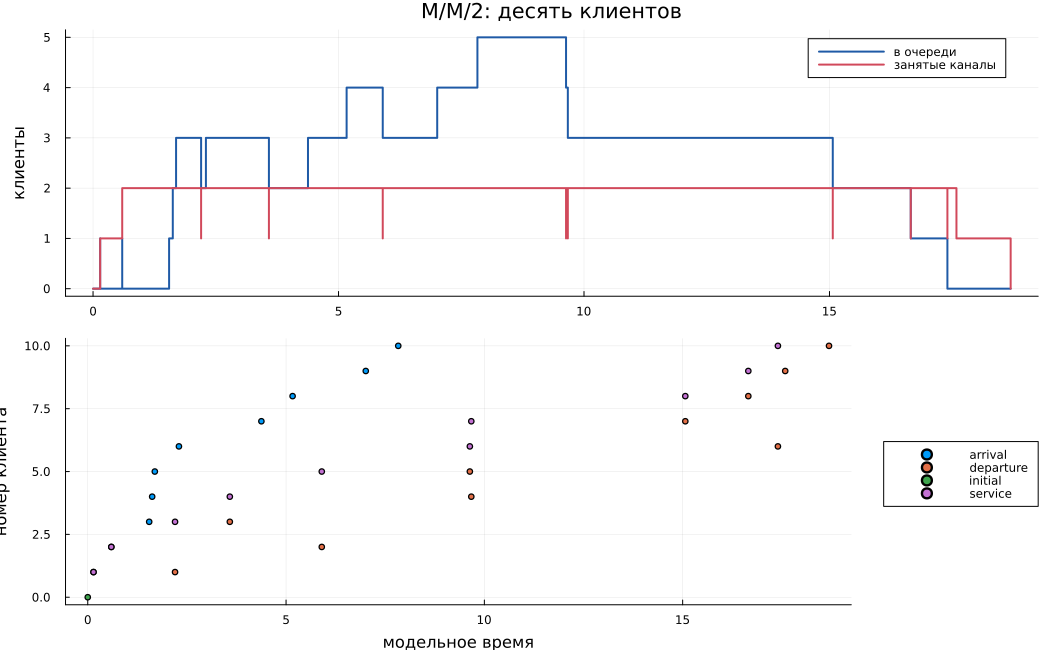

In [3]:
println(first(result.ledger, 10))
println("completion = ", round(result.completion, digits=4))
println("rho = ", theory.rho, ", theoretical Wq = ", round(theory.Wq, digits=4))
figure = queue_state_plot(result.states; title="M/M/2: десять клиентов")
store_figure("queue_baseline", "queue_timeline.png", figure)
figure

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*